In [2]:
%load_ext autoreload
%autoreload 2
from Network import Network, Layer
import torch
import random
import matplotlib.pyplot as plt



In [4]:
inputs = torch.tensor([[0.0,0.0], [0.,1.], [1.,0.], [1., 1.]])
outputs = torch.tensor([0, 1, 1, 0])

In [5]:
# SGD - only use one input
xor_network = Network()
xor_network.layers.append(Layer(2, 4))
xor_network.layers.append(Layer(4, 2, activation_function=torch.nn.Identity()))
mse_errors=[]
for i in range(1000):
    j = random.randint(0,3)
    xor_network.calculate_with_gradient(inputs[j].unsqueeze(0), outputs[j].unsqueeze(0))
    xor_network.update_weights(0.1)
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9779, 0.0221]])
tensor([[0.0077, 0.9923]])
tensor([[0.0193, 0.9807]])
tensor([[0.9893, 0.0107]])


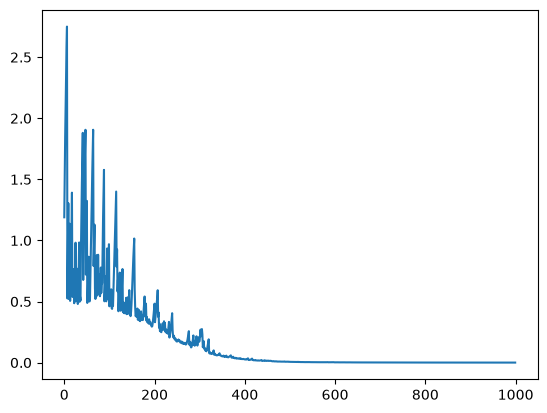

In [6]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x1200 with 14 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>, <Axes: >]], dtype=object))

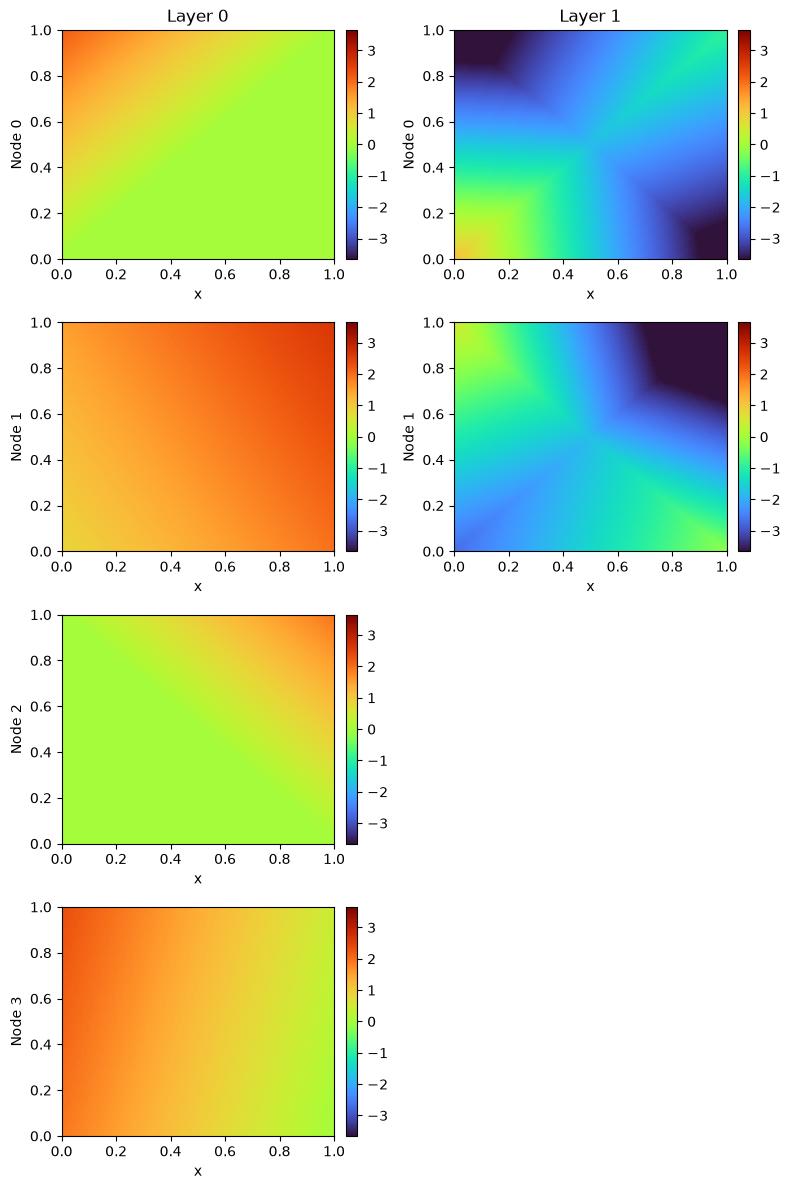

In [7]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [8]:
# Same as above but for sigmoid
xor_network = Network()
xor_network.layers.append(Layer(2, 4, torch.sigmoid))
#xor_network.layers.append(Layer(4, 4, torch.sigmoid))
xor_network.layers.append(Layer(4, 2, torch.nn.Identity()))

mse_errors=[]
for i in range(800):
    for j in random.choices([0, 1, 2, 3], k=1):
        xor_network.calculate_with_gradient(inputs[j].unsqueeze(0), outputs[j].unsqueeze(0))
    
    xor_network.update_weights(2)
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9980, 0.0020]])
tensor([[0.0052, 0.9948]])
tensor([[0.0046, 0.9954]])
tensor([[0.9799, 0.0201]])


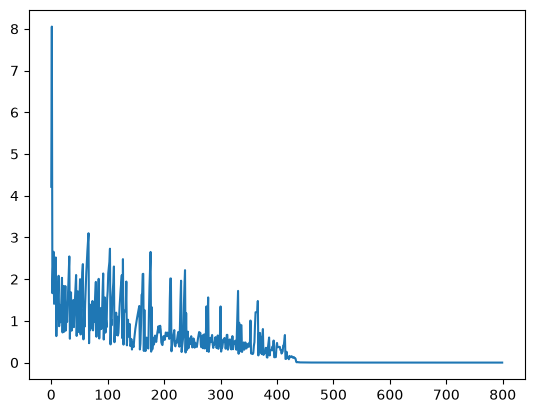

In [9]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x1200 with 14 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>, <Axes: >]], dtype=object))

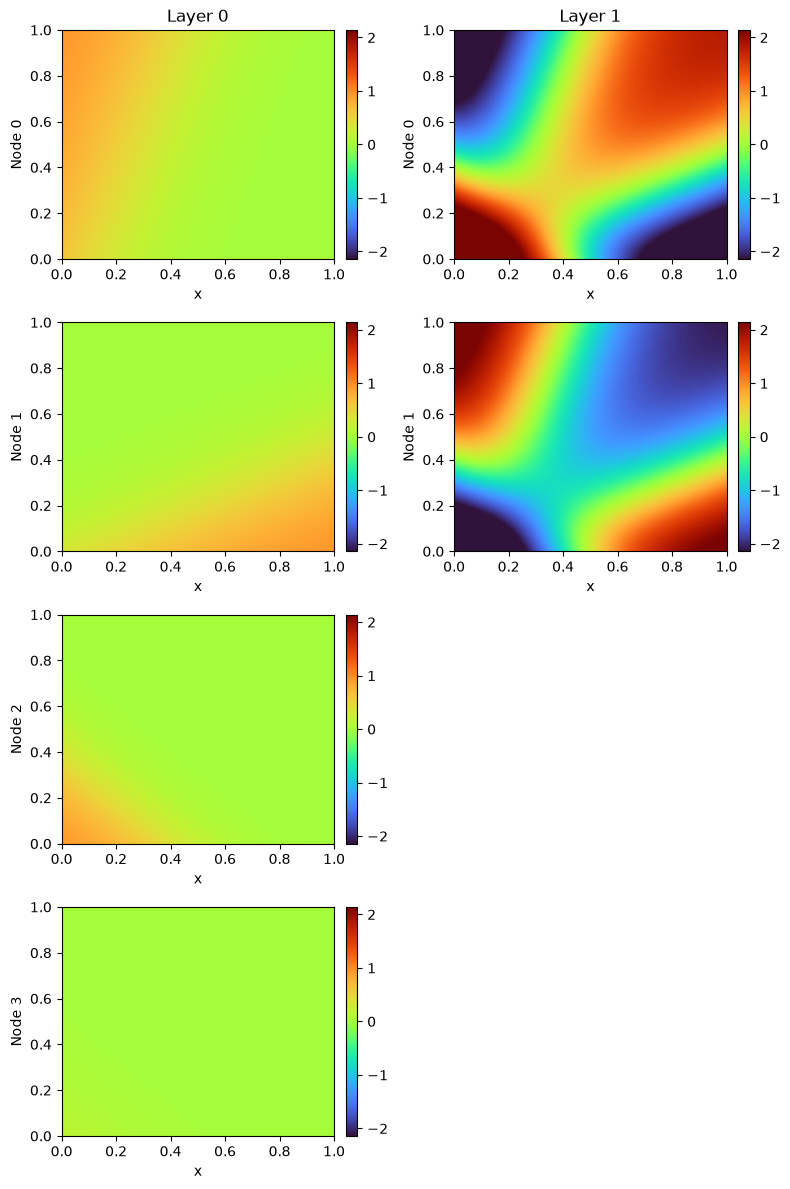

In [10]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [11]:
# Full gradient descent
xor_network = Network()
xor_network.layers.append(Layer(2,4))
xor_network.layers.append(Layer(4,2, torch.nn.Identity()))

mse_errors=[]
for i in range(1000):
    xor_network.calculate_with_gradient(inputs, outputs)

    xor_network.update_weights(1)
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9954, 0.0046]])
tensor([[0.0017, 0.9983]])
tensor([[0.0016, 0.9984]])
tensor([[9.9920e-01, 8.0184e-04]])


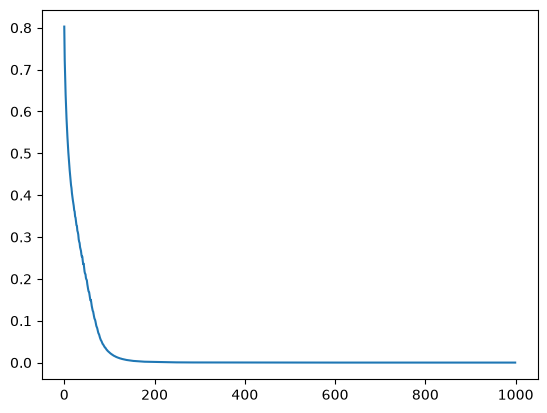

In [10]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x1200 with 14 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>, <Axes: >]], dtype=object))

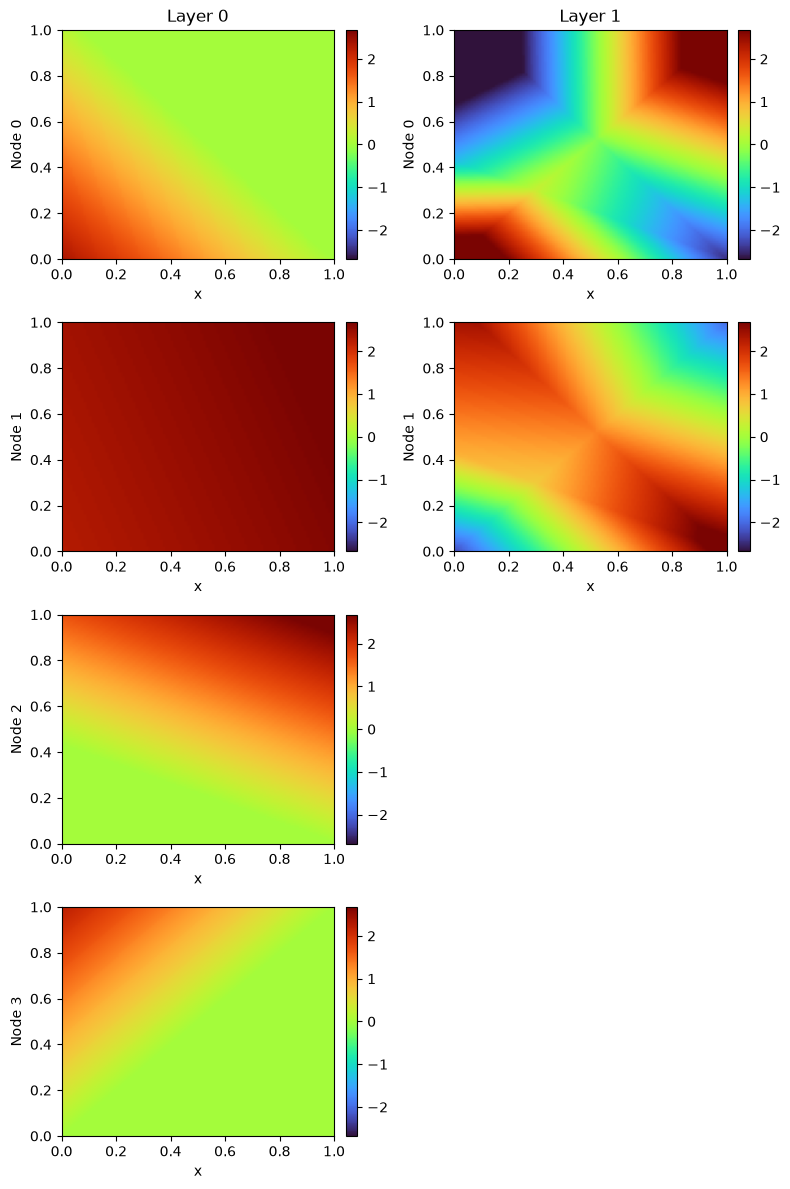

In [11]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [12]:
# Same again but with sigmoid
xor_network = Network()
xor_network.layers.append(Layer(2,4, torch.sigmoid))
xor_network.layers.append(Layer(4,2, torch.nn.Identity()))
mse_errors=[]
for i in range(500):
    xor_network.calculate_with_gradient(inputs, outputs)

    xor_network.update_weights(5)
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9822, 0.0178]])
tensor([[0.0103, 0.9897]])
tensor([[0.0269, 0.9731]])
tensor([[0.9757, 0.0243]])


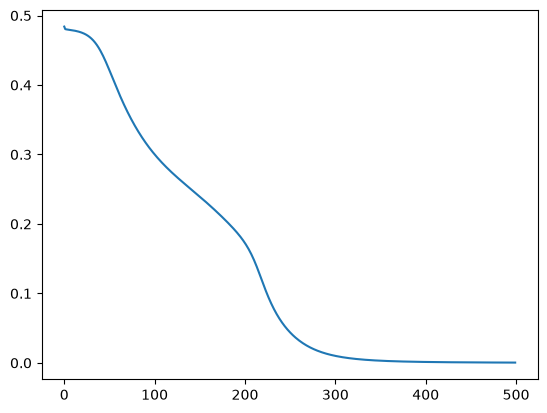

In [13]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x1200 with 14 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>, <Axes: >]], dtype=object))

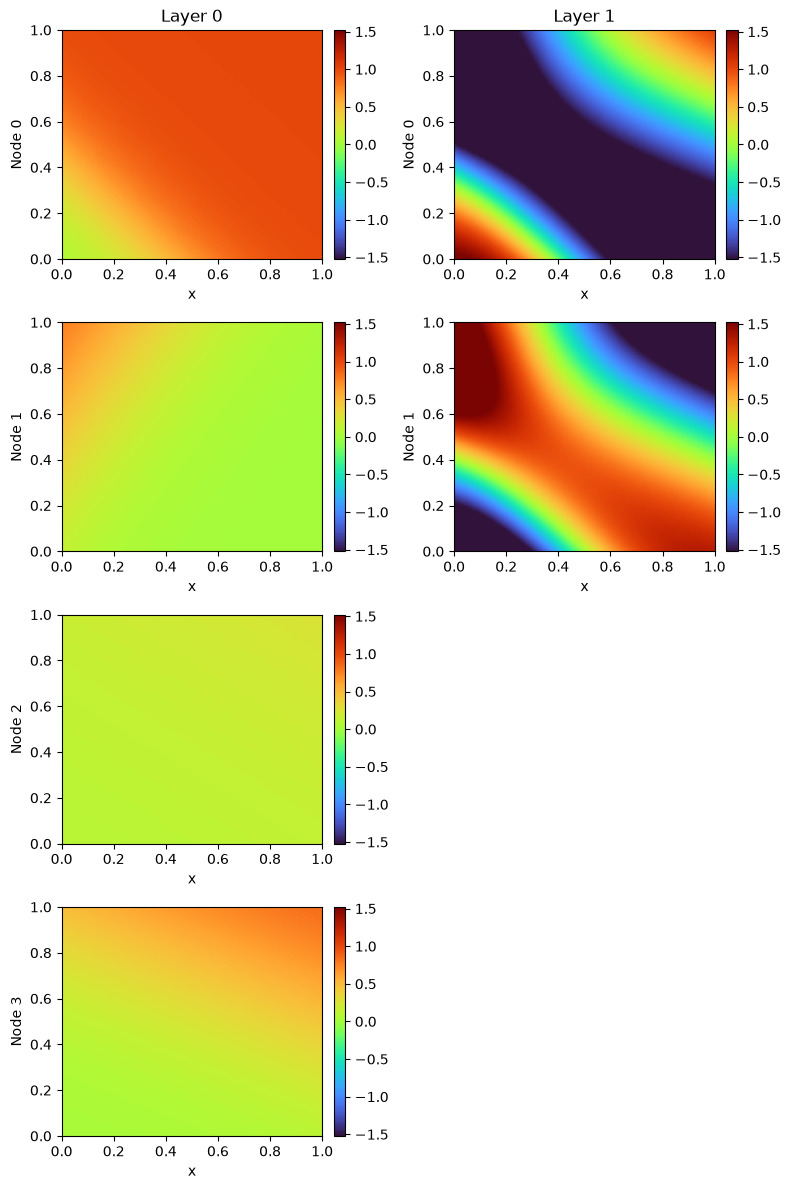

In [14]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps(robust_clip_percentile=10)

In [15]:
# Gradient descent but with very wide/deep network
xor_network = Network()
xor_network.layers.append(Layer(2,5, torch.sigmoid))
xor_network.layers.append(Layer(5,5, torch.sigmoid))
xor_network.layers.append(Layer(5,5, torch.sigmoid))
xor_network.layers.append(Layer(5,2, torch.nn.Identity()))
mse_errors=[]
for i in range(1000):
    xor_network.calculate_with_gradient(inputs, outputs)
    xor_network.update_weights(10)
    mse = 0
    mse = (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs),outputs)**2).mean()
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[9.9928e-01, 7.1791e-04]])
tensor([[8.2367e-04, 9.9918e-01]])
tensor([[7.2527e-04, 9.9927e-01]])
tensor([[9.9954e-01, 4.5760e-04]])


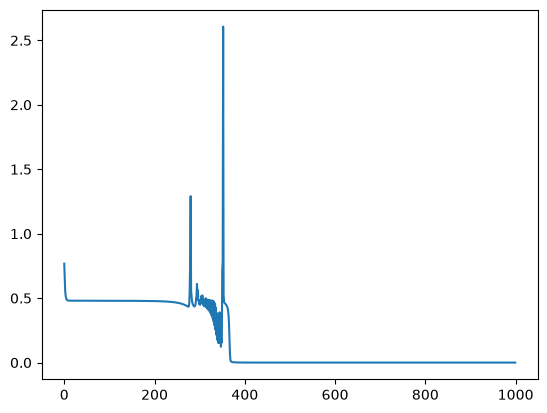

In [16]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 1600x1500 with 37 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 2'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 3'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>,
         <Axes: xlabel='x', ylabel='Node 2'>,
         <Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>,
         <Axes: xlabel='x', ylabel='Node 3'>,
         <Axes: xlabel='x', ylabel='Node 3'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 4'>,
         <Axes: xlabel='x', ylabel='Node 4'>,
         <Axes: xlabel='x', ylabel='Node 4'>, <Axes: >]], dtype=object))

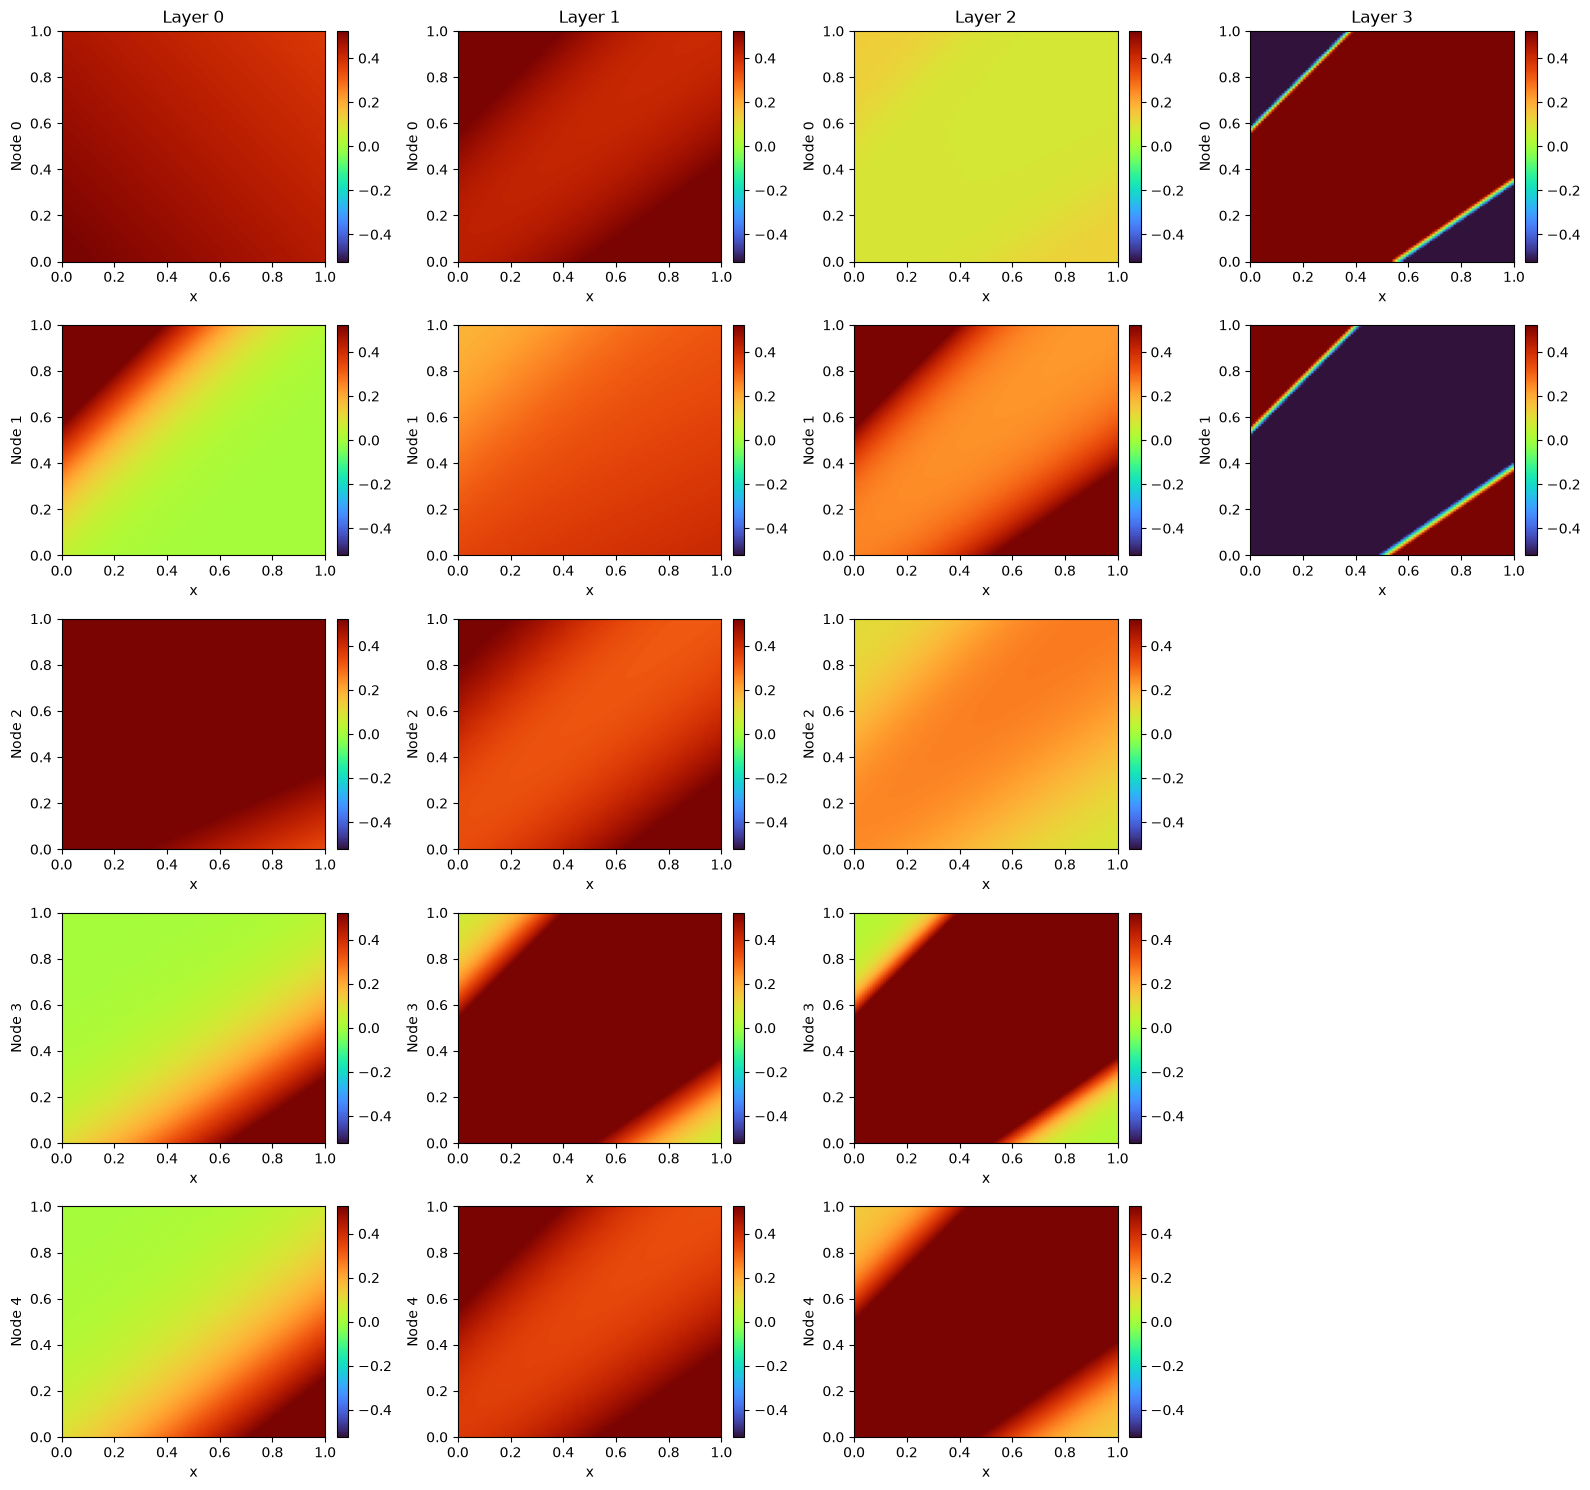

In [17]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps(robust_clip_percentile=30)